In [1]:
#! Final-only dataset metadata access and metrics dependencies
%pip -q install datasets huggingface_hub scikit-learn

In [2]:
#! Common imports, paths and immutable file hashes
import hashlib
import json
import os
import sys

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from google.colab import drive
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from torchvision import models

SEED = 6304
drive.mount('/content/drive')
ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')

PACS_DIR, SHARED_DIR = ROOT / 'data/pacs', ROOT / 'shared'
TASK2_DIR = ROOT / 'task2'
CONFIG_DIR, MODEL_DIR = TASK2_DIR / 'configs', TASK2_DIR / 'models'
RESULT_DIR = TASK2_DIR / 'results/final_eval'
CACHE_DIR = RESULT_DIR / 'feature_cache'
BASE_PATH = CONFIG_DIR / 'base.json'
SPLIT_PATH = SHARED_DIR / 'splits/pacs_sketch_seed6304.json'
INITIAL_PATH = MODEL_DIR / 'resnet18_initial_seed6304.pt'
SOURCE_VAL_PATH = PACS_DIR / 'source_val.csv'
TARGET_MANIFEST_PATH = PACS_DIR / 'target_unlabeled.csv'
PROVENANCE_PATH = PACS_DIR / 'provenance.json'
STUDY_DIR = TASK2_DIR / 'results/dan_strength'
STUDY_PATH = CONFIG_DIR / 'dan_strength_study.json'
LOCK_PATH = RESULT_DIR / 'frozen_evaluation_plan.json'
SOURCE_DOMAINS = ['photo', 'art_painting', 'cartoon']
MAIN_NAMES = ['source_only', 'dan', 'dann', 'cdan']
MODEL_SPECS = {
    'source_only': ('source_only.json', 'source_only_best.pt', 'source_only_last.pt'),
    'dan': ('dan.json', 'dan_best.pt', 'dan_last.pt'),
    'dann': ('dann.json', 'dann_best.pt', 'dann_last.pt'),
    'cdan': ('cdan.json', 'cdan_best.pt', 'cdan_last.pt'),
    'dan_lambda_0p1': ('dan_lambda_0p1.json', 'dan_lambda_0p1_best.pt', 'dan_lambda_0p1_last.pt'),
    'dan_lambda_10': ('dan_lambda_10.json', 'dan_lambda_10_best.pt', 'dan_lambda_10_last.pt'),
}

CONTROL_NAMES = ['dan_lambda_0p1', 'dan', 'dan_lambda_10']

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH_SIZE = 64 if DEVICE.type == 'cuda' else 16

def sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(4 * 1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

print('Device:', DEVICE, '| inference batch size:', BATCH_SIZE)
print('Output folder:', RESULT_DIR)

Mounted at /content/drive
Device: cuda | inference batch size: 64
Output folder: /content/drive/MyDrive/pa1-beyond-iid/task2/results/final_eval


In [3]:
#! Verify completed source-selected checkpoints and lock the evaluation plan
REQUIRED = [BASE_PATH, SPLIT_PATH, INITIAL_PATH, SOURCE_VAL_PATH,
            TARGET_MANIFEST_PATH, PROVENANCE_PATH, STUDY_PATH,
            STUDY_DIR / 'source_validation_all_lambdas.csv',
            STUDY_DIR / 'source_only_selection.json',
            PACS_DIR / 'pacs_sources.tar', PACS_DIR / 'pacs_target_unlabeled.tar',
            SHARED_DIR / 'pacs.py', SHARED_DIR / 'pacs_training.py']

for config_name, best_name, last_name in MODEL_SPECS.values():
    REQUIRED.extend([CONFIG_DIR / config_name, MODEL_DIR / best_name,
                     MODEL_DIR / last_name])

for name in MAIN_NAMES:
    REQUIRED.append(TASK2_DIR / 'results' / name / 'history.csv')

for name in ('0p1', '10'):
    REQUIRED.append(STUDY_DIR / f'lambda_{name}' / 'history.csv')

missing = [str(p) for p in REQUIRED if not p.is_file() or p.stat().st_size == 0]

if missing:
    raise FileNotFoundError('Finish missing Task 2 experiments BEFORE final analysis:\n' + '\n'.join(missing))

base = json.loads(BASE_PATH.read_text())
split = json.loads(SPLIT_PATH.read_text())
provenance = json.loads(PROVENANCE_PATH.read_text())
study = json.loads(STUDY_PATH.read_text())
LABEL_NAMES = list(base['class_names'])
INITIAL_SHA = sha256(INITIAL_PATH)
BASE_SHA, SPLIT_SHA = sha256(BASE_PATH), sha256(SPLIT_PATH)

if (base['seed'] != SEED or split['seed'] != SEED or len(LABEL_NAMES) != 7
        or list(base['source_domains']) != SOURCE_DOMAINS
        or base['target_domain'] != 'sketch'
        or provenance['dataset_revision'] != base['dataset_revision']):
    raise RuntimeError('Task 2A provenance, labels or split do not match the original protocol')

if study['lambda_mmd_values'] != [0.1, 1.0, 10.0]:
    raise RuntimeError('Expected the pre-declared λ={0.1,1,10} controlled study')

if not (STUDY_DIR / 'source_only_selection.json').is_file():
    raise FileNotFoundError('The source-only strength selection is not frozen')

FROZEN_MODELS = {}
for name, (config_name, best_name, last_name) in MODEL_SPECS.items():
    cfg_path, best_path, last_path = (CONFIG_DIR / config_name,
                                     MODEL_DIR / best_name,
                                     MODEL_DIR / last_name)
    cfg = json.loads(cfg_path.read_text())
    best = torch.load(best_path, map_location='cpu', weights_only=True)
    last = torch.load(last_path, map_location='cpu', weights_only=True)
    cfg_sha = sha256(cfg_path)

    if not last.get('finished', False):
        raise RuntimeError(f'{name} training not finished: {last_path}. Resume its training first.')

    if (cfg.get('seed') != SEED or cfg.get('base_config_sha256') != BASE_SHA
            or cfg.get('source_split_sha256') != SPLIT_SHA
            or cfg.get('initial_checkpoint_sha256') != INITIAL_SHA
            or best.get('seed') != SEED
            or best.get('class_names') != LABEL_NAMES
            or best.get('run_config_sha256') != cfg_sha
            or last.get('run_config_sha256') != cfg_sha
            or best.get('initial_checkpoint_sha256') != INITIAL_SHA
            or best.get('epoch') != last.get('best_epoch')
            or not np.isclose(best['best_source_val_mean_macro_f1'],
                              last['best_f1'], atol=1e-8)):
        raise RuntimeError(f'{name} checkpoint/config/provenance inconsistent; inspect before evaluating')

    if (name in ['dann', 'cdan'] and 'discriminator_state_dict' not in best):
        raise RuntimeError(f'{name} domain discriminator checkpoint missing')

    if (best['model_state_dict']['fc.weight'].shape != (7, 512)
            or not all(torch.isfinite(t).all().item()
                       for t in best['model_state_dict'].values() if t.is_floating_point())):
        raise RuntimeError(f'{name} has incompatible or non-finite backbone weights')

    expected_lambda = {'dan': 1.0, 'dan_lambda_0p1': 0.1, 'dan_lambda_10': 10.0}

    if name in expected_lambda and cfg['lambda_mmd'] != expected_lambda[name]:
        raise RuntimeError(f'{name} MMD coefficient does not match its label')

    if name.startswith('dan_lambda_') and not np.isclose(best['lambda_mmd'], expected_lambda[name]):
        raise RuntimeError(f'{name} best checkpoint has the wrong λ')

    FROZEN_MODELS[name] = {
        'config_path': str(cfg_path), 'config_sha256': cfg_sha,
        'best_path': str(best_path), 'best_sha256': sha256(best_path),
        'last_path': str(last_path), 'last_sha256': sha256(last_path),
        'selected_epoch': int(best['epoch']),
        'selected_source_macro_f1': float(best['best_source_val_mean_macro_f1']),
        'training_finished': True,
    }

#! Write the audit trail only after every required check succeeds.
FROZEN_PLAN = {
    'purpose': 'Task 2 final analysis only; NO training or target-based model selection',
    'seed': SEED, 'target_labels_accessed_before_freeze': False,
    'source_split_sha256': SPLIT_SHA, 'base_config_sha256': BASE_SHA,
    'initial_checkpoint_sha256': INITIAL_SHA,
    'dataset_revision': provenance['dataset_revision'],
    'main_comparison': MAIN_NAMES,
    'controlled_study': {'names': CONTROL_NAMES, 'lambdas': [0.1, 1.0, 10.0]},
    'probe': {'source': 'source validation, equal counts sampled evenly from three source domains',
              'target': 'unlabeled Sketch image manifest, equal count',
              'seed': SEED, 'train_fraction': 0.7, 'test_fraction': 0.3,
              'logistic_regression_C': 1, 'class_weight': 'balanced',
              'feature_standardization': 'fit scaler on probe train ONLY'},
    'models': FROZEN_MODELS,
    'study_plan_sha256': sha256(STUDY_PATH),
    'source_choice_sha256': sha256(STUDY_DIR / 'source_only_selection.json'),
}

RESULT_DIR.mkdir(parents=True, exist_ok=True)

if LOCK_PATH.is_file():
    if json.loads(LOCK_PATH.read_text()) != FROZEN_PLAN:
        raise RuntimeError('Previously frozen final-evaluation plan differs. Preserve the old plan; inspect changes.')
else:
    LOCK_PATH.write_text(json.dumps(FROZEN_PLAN, indent=2))

CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('PREFLIGHT PASSED: six finished and source-selected models frozen.')
print('Best epochs:', {k: v['selected_epoch'] for k, v in FROZEN_MODELS.items()})
print('Only now may final target-label evaluation begin.')

PREFLIGHT PASSED: six finished and source-selected models frozen.
Best epochs: {'source_only': 9, 'dan': 8, 'dann': 10, 'cdan': 3, 'dan_lambda_0p1': 9, 'dan_lambda_10': 1}
Only now may final target-label evaluation begin.


In [4]:
#! Prepare local images once and construct evaluation-only data loaders
sys.path.insert(0, str(SHARED_DIR))
from pacs import PACSDataset, make_transform, prepare_local_data

LOCAL_ROOT = Path('/content/pacs_task2_final_eval')

prepare_local_data(PACS_DIR, LOCAL_ROOT, include_target=True)

SOURCE_ROWS = pd.read_csv(SOURCE_VAL_PATH)
TARGET_ROWS = pd.read_csv(TARGET_MANIFEST_PATH)
SOURCE_ROWS = SOURCE_ROWS.reset_index(drop=True)
TARGET_ROWS = TARGET_ROWS.reset_index(drop=True)

if {'label', 'label_name'} & set(TARGET_ROWS.columns):
    raise RuntimeError('Target manifest must remain unlabeled')

if TARGET_ROWS['hf_index'].duplicated().any() or SOURCE_ROWS['hf_index'].duplicated().any():
    raise RuntimeError('Image identifiers must be unique in each role')

SOURCE_LOADERS, SOURCE_METADATA = {}, {}

for domain in SOURCE_DOMAINS:
    ds = PACSDataset(SOURCE_VAL_PATH, LOCAL_ROOT, make_transform(False), domain=domain)
    rows = SOURCE_ROWS[SOURCE_ROWS.domain == domain].reset_index(drop=True)

    if len(ds) != len(rows) or len(ds) == 0:
        raise RuntimeError(f'Unexpected {domain} validation images')

    SOURCE_LOADERS[domain] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
                                        pin_memory=DEVICE.type == 'cuda')
    SOURCE_METADATA[domain] = rows

TARGET_DATASET = PACSDataset(TARGET_MANIFEST_PATH, LOCAL_ROOT, make_transform(False),
                             unlabeled=True)
TARGET_LOADER = DataLoader(TARGET_DATASET, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=DEVICE.type == 'cuda')

if len(TARGET_DATASET) != len(TARGET_ROWS) or len(TARGET_DATASET) == 0:
    raise RuntimeError('Target manifest and image loader disagree')

#! A fixed, class-blind, domain-balanced probe sample (same IDs for every model).
rng = np.random.default_rng(SEED)
per_domain = min(min(len(SOURCE_METADATA[d]) for d in SOURCE_DOMAINS),
                 len(TARGET_ROWS) // len(SOURCE_DOMAINS))

n_probe = per_domain * len(SOURCE_DOMAINS)

if per_domain < 5:
    raise RuntimeError('Not enough source or target examples for a reproducible probe')

SOURCE_PROBE_INDICES = []
position = 0

for domain in SOURCE_DOMAINS:
    size = len(SOURCE_METADATA[domain])
    SOURCE_PROBE_INDICES.extend((position + rng.choice(size, per_domain, replace=False)).tolist())
    position += size

SOURCE_PROBE_INDICES = np.asarray(SOURCE_PROBE_INDICES, dtype=np.int64)
TARGET_PROBE_INDICES = np.asarray(rng.choice(len(TARGET_ROWS), n_probe, replace=False), dtype=np.int64)
PROBE_LABELS = np.r_[np.zeros(n_probe, dtype=np.int64), np.ones(n_probe, dtype=np.int64)]
PROBE_TRAIN, PROBE_TEST = train_test_split(np.arange(2 * n_probe), test_size=0.3,
                                           random_state=SEED, stratify=PROBE_LABELS)
PROBE_PLAN = {
    'source_hf_indices': [int(x) for x in np.concatenate([
        SOURCE_METADATA[d]['hf_index'].to_numpy() for d in SOURCE_DOMAINS
    ])[SOURCE_PROBE_INDICES]],
    'target_hf_indices': [int(x) for x in TARGET_ROWS['hf_index'].to_numpy()[TARGET_PROBE_INDICES]],
    'train_positions': PROBE_TRAIN.tolist(),
    'test_positions': PROBE_TEST.tolist(),
    'per_source_domain': int(per_domain),
    'each_binary_domain': int(n_probe), 'seed': SEED,
}

probe_file = RESULT_DIR / 'domain_probe_fixed_sample.json'

if probe_file.is_file() and json.loads(probe_file.read_text()) != PROBE_PLAN:
    raise RuntimeError('A previously saved domain-probe sample differs; do not silently replace it')

if not probe_file.is_file():
    probe_file.write_text(json.dumps(PROBE_PLAN, indent=2))

print('Source validation sizes:', {d: len(SOURCE_METADATA[d]) for d in SOURCE_DOMAINS})
print('Target evaluation images:', len(TARGET_ROWS))
print('Probe: source=', n_probe, 'Sketch=', n_probe, '| fixed 70/30 train/test')

Source validation sizes: {'photo': 334, 'art_painting': 410, 'cartoon': 469}
Target evaluation images: 3929
Probe: source= 1002 Sketch= 1002 | fixed 70/30 train/test


In [5]:
#! Frozen model inference and provenance-validated per-method feature caching
import tempfile

SOURCE_IDS = np.concatenate([SOURCE_METADATA[d]['hf_index'].to_numpy(dtype=np.int64)
                             for d in SOURCE_DOMAINS])
SOURCE_TRUE = np.concatenate([SOURCE_METADATA[d]['label'].to_numpy(dtype=np.int64)
                              for d in SOURCE_DOMAINS])
TARGET_IDS = TARGET_ROWS['hf_index'].to_numpy(dtype=np.int64)
SOURCE_SHA, TARGET_SHA = sha256(SOURCE_VAL_PATH), sha256(TARGET_MANIFEST_PATH)

def feature_logits(model, x):
    #! Explicit torchvision ResNet-18 forward to expose its pre-FC pooled representation.
    x = model.conv1(x)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)
    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)
    features = torch.flatten(model.avgpool(x), 1)
    return features, model.fc(features)

@torch.inference_mode()

def collect(model, loader, labeled):
    vectors, logits_list, labels = [], [], []

    for batch in loader:
        if labeled:
            image, truth = batch
            labels.append(truth.numpy())
        else:
            image = batch

        features, scores = feature_logits(model, image.to(DEVICE, non_blocking=True))
        vectors.append(features.cpu().numpy().astype(np.float32))
        logits_list.append(scores.cpu().numpy().astype(np.float32))

    vectors, logits_list = np.concatenate(vectors), np.concatenate(logits_list)

    if not (vectors.shape[1] == 512 and logits_list.shape == (len(vectors), 7)
            and np.isfinite(vectors).all() and np.isfinite(logits_list).all()):
        raise RuntimeError('Non-finite or unexpected frozen inference output')

    return vectors, logits_list, np.concatenate(labels) if labeled else None

#! Confirm feature-forward equivalence with torchvision's official forward before inference.
probe_model = models.resnet18(weights=None)
probe_model.fc = torch.nn.Linear(probe_model.fc.in_features, 7)
probe_model.load_state_dict(torch.load(MODEL_DIR / MODEL_SPECS['source_only'][1],
                                       map_location='cpu', weights_only=True)['model_state_dict'])

probe_model = probe_model.to(DEVICE).eval()

with torch.inference_mode():
    tiny = torch.randn(2, 3, 64, 64, device=DEVICE)
    _f, _logits = feature_logits(probe_model, tiny)
    _official = probe_model(tiny)

if _f.shape != (2, 512) or not torch.allclose(_logits, _official, atol=1e-5, rtol=1e-5):
    raise RuntimeError('Feature-forward path does not reproduce official ResNet logits')

del probe_model, tiny, _f, _logits, _official

if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()

FEATURES = {}

for name in MODEL_SPECS:
    entry = FROZEN_MODELS[name]
    cache_path = CACHE_DIR / (name + '_source_target_features.npz')
    cache_meta = CACHE_DIR / (name + '_metadata.json')
    expected = {'checkpoint_sha256': entry['best_sha256'],
                'source_val_manifest_sha256': SOURCE_SHA,
                'target_unlabeled_manifest_sha256': TARGET_SHA,
                'seed': SEED, 'transform': base['eval_transform'], 'precision': 'float32'}

    if cache_path.is_file() or cache_meta.is_file():
        if not (cache_path.is_file() and cache_meta.is_file()
                and json.loads(cache_meta.read_text()).get('config') == expected
                and json.loads(cache_meta.read_text()).get('cache_sha256') == sha256(cache_path)):
            raise RuntimeError(f'{name} has an incomplete/stale feature cache; preserve and inspect it')

        with np.load(cache_path, allow_pickle=False) as archive:
            result = {key: archive[key] for key in archive.files}

        print(name, ': reused validated feature metadata')
    else:
        model = models.resnet18(weights=None)
        model.fc = torch.nn.Linear(model.fc.in_features, 7)
        best = torch.load(entry['best_path'], map_location='cpu', weights_only=True)
        model.load_state_dict(best['model_state_dict'], strict=True)
        model = model.to(DEVICE).eval()

        features_s, logits_s, label_parts = [], [], []

        for domain in SOURCE_DOMAINS:
            f, z, y = collect(model, SOURCE_LOADERS[domain], labeled=True)

            if not np.array_equal(y, SOURCE_METADATA[domain]['label'].to_numpy(dtype=np.int64)):
                raise RuntimeError(f'{name} source label/order mismatch in {domain}')

            features_s.append(f); logits_s.append(z); label_parts.append(y)
        ft, zt, _ = collect(model, TARGET_LOADER, labeled=False)

        result = {'source_features': np.concatenate(features_s),
                  'source_logits': np.concatenate(logits_s),
                  'target_features': ft, 'target_logits': zt,
                  'source_hf_indices': SOURCE_IDS, 'target_hf_indices': TARGET_IDS,
                  'source_labels': np.concatenate(label_parts)}

        #! Stage on the Colab machine, then atomically publish to Drive.
        with tempfile.TemporaryDirectory(dir='/content') as temp_dir:
            local = Path(temp_dir) / 'features.npz'
            np.savez_compressed(local, **result)
            staged = cache_path.with_suffix('.npz.partial')
            import shutil
            shutil.copy2(local, staged)
            os.replace(staged, cache_path)

        cache_meta.write_text(json.dumps({'config': expected,
                                          'cache_sha256': sha256(cache_path)}, indent=2))

        print(name, ': extracted', len(SOURCE_IDS), 'source +', len(TARGET_IDS), 'target images')
        del model

        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    if (not np.array_equal(result['source_hf_indices'], SOURCE_IDS)
            or not np.array_equal(result['target_hf_indices'], TARGET_IDS)
            or not np.array_equal(result['source_labels'], SOURCE_TRUE)
            or result['source_features'].shape != (len(SOURCE_IDS), 512)
            or result['target_features'].shape != (len(TARGET_IDS), 512)
            or result['source_logits'].shape != (len(SOURCE_IDS), 7)
            or result['target_logits'].shape != (len(TARGET_IDS), 7)
            or not all(np.isfinite(result[k]).all() for k in
                       ('source_features', 'target_features', 'source_logits', 'target_logits'))):
        raise RuntimeError(f'{name} cached arrays have inconsistent identities/shapes/non-finite values')

    FEATURES[name] = result

print('FEATURE EXTRACTION COMPLETE; Sketch labels have not been loaded.')

source_only : extracted 1213 source + 3929 target images
dan : extracted 1213 source + 3929 target images
dann : extracted 1213 source + 3929 target images
cdan : extracted 1213 source + 3929 target images
dan_lambda_0p1 : extracted 1213 source + 3929 target images
dan_lambda_10 : extracted 1213 source + 3929 target images
FEATURE EXTRACTION COMPLETE; Sketch labels have not been loaded.


In [6]:
#! Source metrics, binary domain probe and pre-label evidence
SOURCE_RESULT_ROWS, PROBE_ROWS = [], []

def classification_metrics(y, predicted):
    return {'accuracy': float(accuracy_score(y, predicted)),
            'macro_f1': float(f1_score(y, predicted, labels=np.arange(7),
                                       average='macro', zero_division=0))}

def domain_probe(source_features, target_features):
    xs = source_features[SOURCE_PROBE_INDICES]
    xt = target_features[TARGET_PROBE_INDICES]
    X = np.concatenate((xs, xt), axis=0)

    if len(X) != len(PROBE_LABELS) or not np.isfinite(X).all():
        raise RuntimeError('Invalid balanced probe feature array')

    probe = make_pipeline(StandardScaler(), LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=2000, random_state=SEED))

    probe.fit(X[PROBE_TRAIN], PROBE_LABELS[PROBE_TRAIN])

    return float(accuracy_score(PROBE_LABELS[PROBE_TEST], probe.predict(X[PROBE_TEST])))

for name, result in FEATURES.items():
    predictions = result['source_logits'].argmax(axis=1)
    offset, accuracies, f1s = 0, [], []

    for domain in SOURCE_DOMAINS:
        n = len(SOURCE_METADATA[domain])
        metrics = classification_metrics(SOURCE_TRUE[offset:offset+n], predictions[offset:offset+n])
        SOURCE_RESULT_ROWS.append({'method': name, 'domain': domain, 'n_images': n, **metrics})
        accuracies.append(metrics['accuracy']); f1s.append(metrics['macro_f1'])
        offset += n

    SOURCE_RESULT_ROWS.append({'method': name, 'domain': 'mean', 'n_images': len(SOURCE_TRUE),
                               'accuracy': float(np.mean(accuracies)), 'macro_f1': float(np.mean(f1s))})
    SOURCE_RESULT_ROWS.append({'method': name, 'domain': 'worst', 'n_images': len(SOURCE_TRUE),
                               'accuracy': float(np.min(accuracies)), 'macro_f1': float(np.min(f1s))})

    if not np.isclose(np.mean(f1s), FROZEN_MODELS[name]['selected_source_macro_f1'],
                      atol=2e-5, rtol=0):
        raise RuntimeError(f'{name} re-evaluation disagrees with its selected source F1; inspect preprocessing')

    PROBE_ROWS.append({'method': name,
                       'domain_separability': domain_probe(result['source_features'],
                                                            result['target_features']),
                       'probe_samples_per_domain': n_probe,
                       'probe_train_n': len(PROBE_TRAIN), 'probe_test_n': len(PROBE_TEST)})

SOURCE_TABLE = pd.DataFrame(SOURCE_RESULT_ROWS)
PROBE_TABLE = pd.DataFrame(PROBE_ROWS)
SOURCE_TABLE.to_csv(RESULT_DIR / 'source_validation_all_methods.csv', index=False)
PROBE_TABLE.to_csv(RESULT_DIR / 'domain_separability_all_methods.csv', index=False)

print('Source validation (means):')

display(SOURCE_TABLE[(SOURCE_TABLE.method.isin(MAIN_NAMES)) &
                     (SOURCE_TABLE.domain == 'mean')].round(4))

print('Held-out domain separability; chance ~0.50:')

display(PROBE_TABLE[PROBE_TABLE.method.isin(MAIN_NAMES)].round(4))

Source validation (means):


,method,domain,n_images,accuracy,macro_f1
3,source_only,mean,1213,0.9457,0.9462
8,dan,mean,1213,0.9531,0.9538
13,dann,mean,1213,0.3128,0.2515
18,cdan,mean,1213,0.3438,0.2158


Held-out domain separability; chance ~0.50:


,method,domain_separability,probe_samples_per_domain,probe_train_n,probe_test_n
0,source_only,0.9983,1002,1402,602
1,dan,0.8040,1002,1402,602
2,dann,0.9734,1002,1402,602
3,cdan,0.9934,1002,1402,602


In [7]:
#! Recover ground-truth Sketch labels only after experimental freeze
from datasets import load_dataset

if not LOCK_PATH.is_file() or json.loads(LOCK_PATH.read_text()) != FROZEN_PLAN:
    raise RuntimeError('Target labels forbidden until all settings/checkpoints are frozen')

PINNED_DATA = load_dataset(provenance['dataset_repo'], split='train',
                           revision=provenance['dataset_revision'])

if len(PINNED_DATA) <= max(int(SOURCE_IDS.max()), int(TARGET_IDS.max())):
    raise RuntimeError('Pinned dataset is shorter than original HF image indices')

if list(PINNED_DATA.features['label'].names) != LABEL_NAMES:
    raise RuntimeError('Label mapping differs from frozen PACS protocol')

#! Read label and domain columns directly: do not decode 4,000+ image rows.
ALL_LABELS = np.asarray(PINNED_DATA['label'], dtype=np.int64)
ALL_DOMAINS = np.asarray(PINNED_DATA['domain'])

if not np.array_equal(ALL_LABELS[SOURCE_IDS], SOURCE_TRUE):
    raise RuntimeError('Pinned dataset source label/row mapping mismatch')

TARGET_TRUE = ALL_LABELS[TARGET_IDS].copy()

if (len(TARGET_TRUE) != len(TARGET_IDS) or not np.isin(TARGET_TRUE, np.arange(7)).all()
        or not np.all(ALL_DOMAINS[TARGET_IDS] == 'sketch')):
    raise RuntimeError('Target labels/domain do not align with original image identifiers')

del PINNED_DATA, ALL_LABELS, ALL_DOMAINS

print('FINAL ANALYSIS ONLY: recovered labels for', len(TARGET_TRUE), 'Sketch images.')
print('No checkpoint, optimizer or training data is changed by this cell.')

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  191MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9991 [00:00<?, ? examples/s]

FINAL ANALYSIS ONLY: recovered labels for 3929 Sketch images.
No checkpoint, optimizer or training data is changed by this cell.


In [8]:
#! Target metrics and paired class-level analysis; no retraining
TARGET_ROWS_RESULT, PREDICTIONS = [], {}

for name, result in FEATURES.items():
    predicted = result['target_logits'].argmax(axis=1)
    PREDICTIONS[name] = predicted
    metrics = classification_metrics(TARGET_TRUE, predicted)
    TARGET_ROWS_RESULT.append({'method': name, 'n_target': len(TARGET_TRUE), **metrics})

TARGET_TABLE = pd.DataFrame(TARGET_ROWS_RESULT)
REFERENCE_ACCURACY = float(TARGET_TABLE.set_index('method').loc['source_only', 'accuracy'])
TARGET_TABLE['accuracy_delta_vs_erm_pp'] = (TARGET_TABLE['accuracy'] - REFERENCE_ACCURACY) * 100
TARGET_TABLE.to_csv(RESULT_DIR / 'target_metrics_all_methods.csv', index=False)

MAIN_ROWS = []
for name in MAIN_NAMES:
    vals = SOURCE_TABLE[(SOURCE_TABLE.method == name) & (SOURCE_TABLE.domain == 'mean')].iloc[0]
    target = TARGET_TABLE[TARGET_TABLE.method == name].iloc[0]
    main_probe = PROBE_TABLE[PROBE_TABLE.method == name].iloc[0]

    row = {'method': name, 'source_mean_accuracy': vals.accuracy,
           'source_mean_macro_f1': vals.macro_f1,
           'target_accuracy': target.accuracy, 'target_macro_f1': target.macro_f1,
           'target_accuracy_delta_vs_erm_pp': target.accuracy_delta_vs_erm_pp,
           'domain_separability': main_probe.domain_separability,
           'selected_epoch': FROZEN_MODELS[name]['selected_epoch']}

    for domain in SOURCE_DOMAINS:
        m = SOURCE_TABLE[(SOURCE_TABLE.method == name) & (SOURCE_TABLE.domain == domain)].iloc[0]
        row[f'{domain}_accuracy'] = m.accuracy
        row[f'{domain}_macro_f1'] = m.macro_f1

    MAIN_ROWS.append(row)

MAIN_TABLE = pd.DataFrame(MAIN_ROWS)
MAIN_TABLE.to_csv(RESULT_DIR / 'main_comparison.csv', index=False)

CLASS_ROWS, CONFUSIONS = [], {}
erm_pred = PREDICTIONS['source_only']

for name in MODEL_SPECS:
    pred = PREDICTIONS[name]
    matrix = confusion_matrix(TARGET_TRUE, pred, labels=np.arange(7))
    CONFUSIONS[name] = matrix

    pd.DataFrame(matrix, index=LABEL_NAMES, columns=LABEL_NAMES).to_csv(
        RESULT_DIR / f'confusion_{name}.csv')

    for index, label in enumerate(LABEL_NAMES):
        mask = TARGET_TRUE == index

        if mask.sum() == 0:
            raise RuntimeError(f'No Sketch examples for class {label}')

        correct = float(np.mean(pred[mask] == index))
        baseline = float(np.mean(erm_pred[mask] == index))

        offdiag = matrix[index].copy(); offdiag[index] = -1
        other = int(offdiag.argmax())

        CLASS_ROWS.append({'method': name, 'class_id': index, 'class_name': label,
                           'class_n': int(mask.sum()), 'class_accuracy': correct,
                           'erm_class_accuracy': baseline,
                           'change_vs_erm_pp': (correct - baseline) * 100,
                           'dominant_confusion': LABEL_NAMES[other],
                           'dominant_confusion_count': int(offdiag[other]),
                           'wrong_to_correct_vs_erm': int(np.sum(mask & (erm_pred != index) & (pred == index))),
                           'correct_to_wrong_vs_erm': int(np.sum(mask & (erm_pred == index) & (pred != index)))})

CLASS_TABLE = pd.DataFrame(CLASS_ROWS)
CLASS_TABLE.to_csv(RESULT_DIR / 'per_class_target_transfer.csv', index=False)

prediction_archive = pd.DataFrame({'hf_index': TARGET_IDS, 'true_label': TARGET_TRUE,
                                    'true_class': [LABEL_NAMES[i] for i in TARGET_TRUE]})

for name in MODEL_SPECS:
    prediction_archive[name + '_prediction'] = PREDICTIONS[name]
    prediction_archive[name + '_predicted_class'] = [LABEL_NAMES[i] for i in PREDICTIONS[name]]

prediction_archive.to_csv(RESULT_DIR / 'paired_target_predictions.csv', index=False)

CONTROL_TABLE = []

for lam, name in zip([0.1, 1.0, 10.0], CONTROL_NAMES):
    s = SOURCE_TABLE[(SOURCE_TABLE.method == name) & (SOURCE_TABLE.domain == 'mean')].iloc[0]
    t = TARGET_TABLE[TARGET_TABLE.method == name].iloc[0]
    p = PROBE_TABLE[PROBE_TABLE.method == name].iloc[0]

    CONTROL_TABLE.append({'lambda_mmd': lam, 'method': name,
                          'source_mean_accuracy': s.accuracy,
                          'source_mean_macro_f1': s.macro_f1,
                          'target_accuracy': t.accuracy, 'target_macro_f1': t.macro_f1,
                          'target_delta_vs_erm_pp': t.accuracy_delta_vs_erm_pp,
                          'domain_separability': p.domain_separability,
                          'selected_epoch': FROZEN_MODELS[name]['selected_epoch']})

CONTROL_TABLE = pd.DataFrame(CONTROL_TABLE)
CONTROL_TABLE.to_csv(RESULT_DIR / 'controlled_strength_final.csv', index=False)

print('MAIN FOUR-METHOD COMPARISON:')
display(MAIN_TABLE.round(4))
print('CONTROLLED λ STUDY:')
display(CONTROL_TABLE.round(4))
print('CLASS-WISE TRANSFER EVIDENCE:')
display(CLASS_TABLE[CLASS_TABLE.method.isin(MAIN_NAMES)].round(3))

MAIN FOUR-METHOD COMPARISON:


,method,source_mean_accuracy,source_mean_macro_f1,target_accuracy,target_macro_f1,target_accuracy_delta_vs_erm_pp,domain_separability,selected_epoch,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1
0,source_only,0.9457,0.9462,0.6714,0.6781,0.0000,0.9983,9,0.9760,0.9726,0.9122,0.9136,0.9488,0.9524
1,dan,0.9531,0.9538,0.5561,0.5240,-11.5297,0.8040,8,0.9820,0.9791,0.9220,0.9243,0.9552,0.9581
2,dann,0.3128,0.2515,0.1881,0.1081,-48.3329,0.9734,10,0.4461,0.3223,0.2512,0.2310,0.2409,0.2012
3,cdan,0.3438,0.2158,0.1247,0.0778,-54.6704,0.9934,3,0.4311,0.2204,0.2463,0.1319,0.3539,0.2951


CONTROLLED λ STUDY:


,lambda_mmd,method,source_mean_accuracy,source_mean_macro_f1,target_accuracy,target_macro_f1,target_delta_vs_erm_pp,domain_separability,selected_epoch
0,0.1,dan_lambda_0p1,0.9431,0.9443,0.7190,0.6640,4.7595,0.9585,9
1,1.0,dan,0.9531,0.9538,0.5561,0.5240,-11.5297,0.8040,8
2,10.0,dan_lambda_10,0.2166,0.0507,0.0407,0.0112,-63.0695,0.8322,1


CLASS-WISE TRANSFER EVIDENCE:


,method,class_id,class_name,class_n,class_accuracy,erm_class_accuracy,change_vs_erm_pp,dominant_confusion,dominant_confusion_count,wrong_to_correct_vs_erm,correct_to_wrong_vs_erm
0,source_only,0,dog,772,0.323,0.323,0.000,elephant,297,0,0
1,source_only,1,elephant,740,0.946,0.946,0.000,dog,18,0,0
2,source_only,2,giraffe,753,0.765,0.765,0.000,elephant,66,0,0
3,source_only,3,guitar,608,0.970,0.970,0.000,elephant,16,0,0
4,source_only,4,horse,816,0.440,0.440,0.000,elephant,194,0,0
5,source_only,5,house,80,0.962,0.962,0.000,guitar,2,0,0
6,source_only,6,person,160,0.544,0.544,0.000,elephant,40,0,0
7,dan,0,dog,772,0.440,0.323,11.788,person,304,180,89
8,dan,1,elephant,740,0.578,0.946,-36.757,person,206,5,277
9,dan,2,giraffe,753,0.625,0.765,-13.944,person,99,63,168


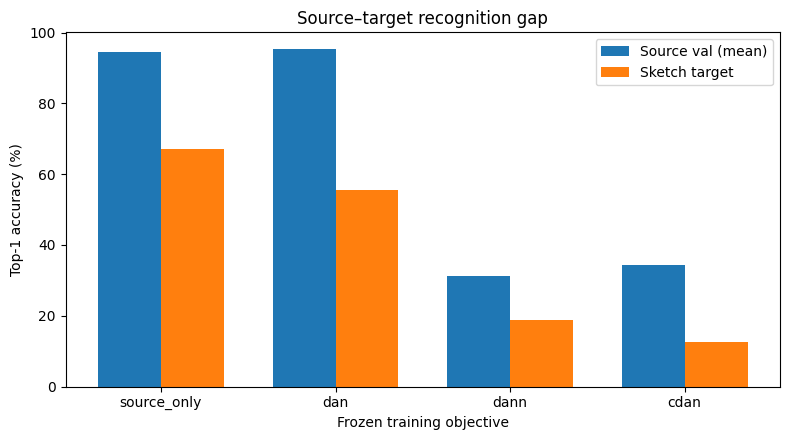

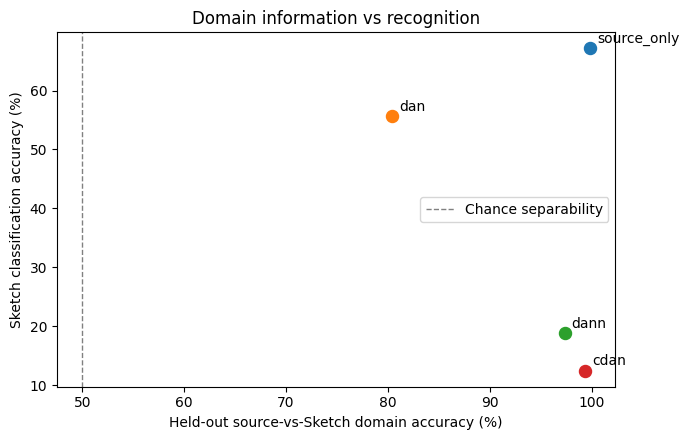

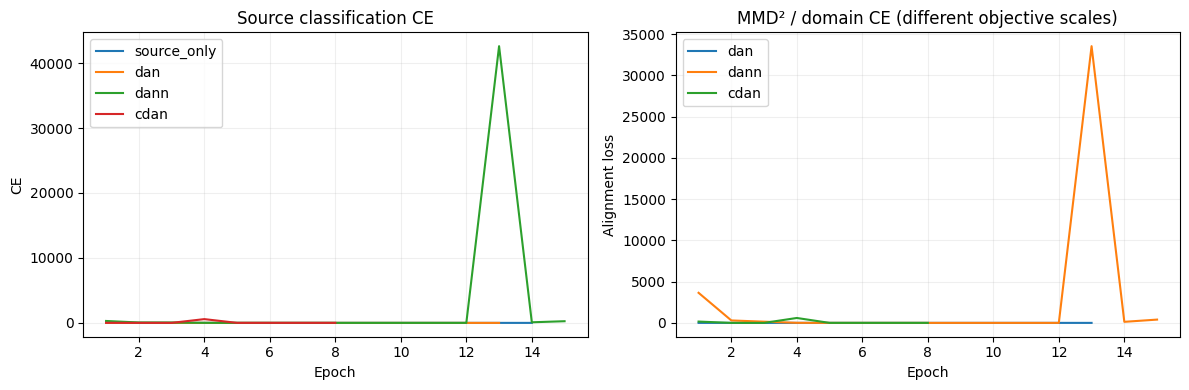

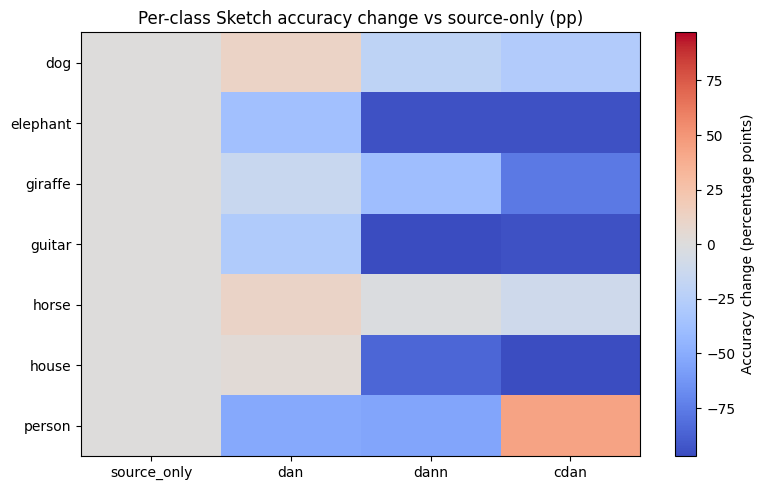

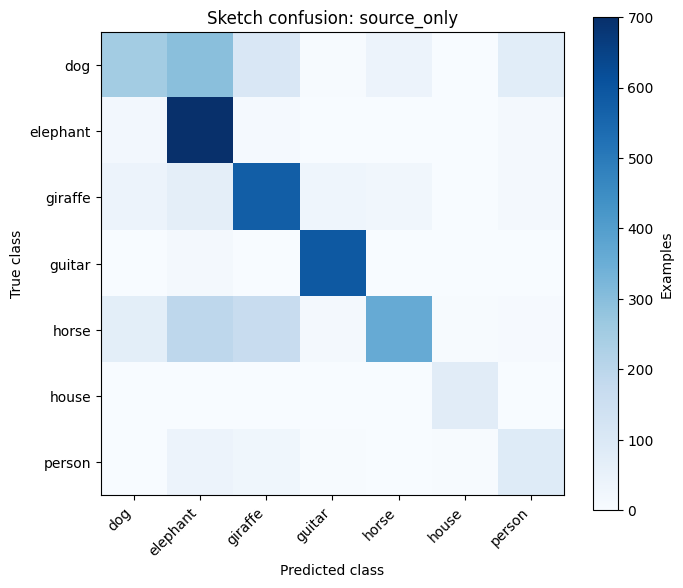

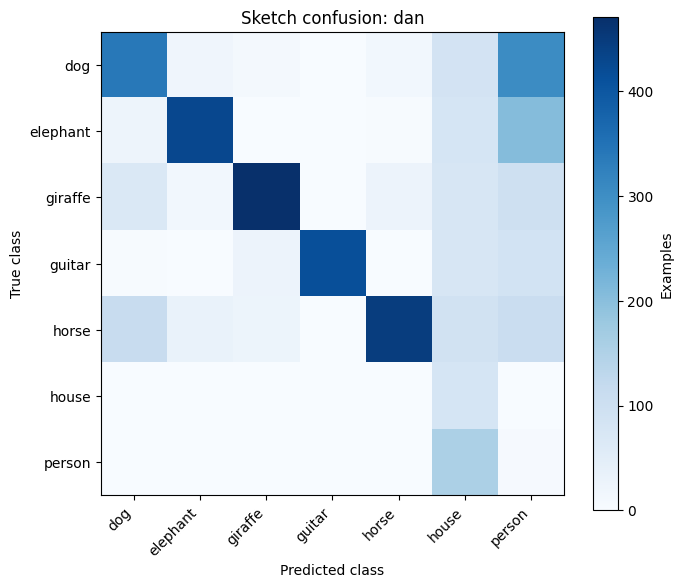

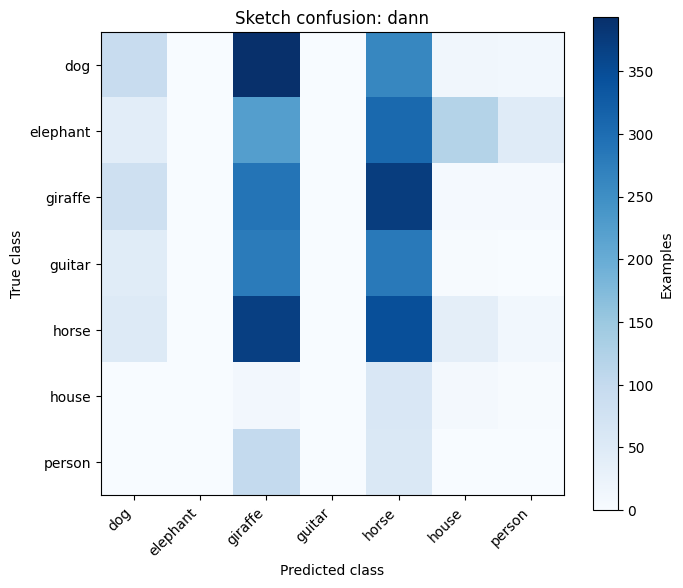

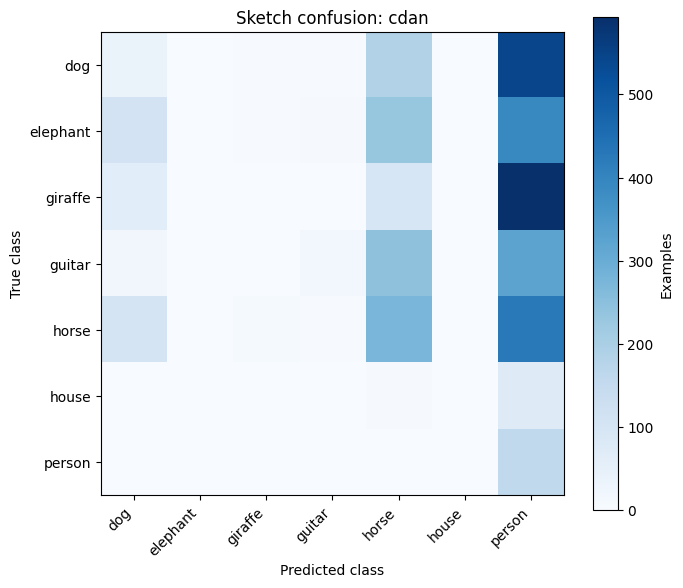

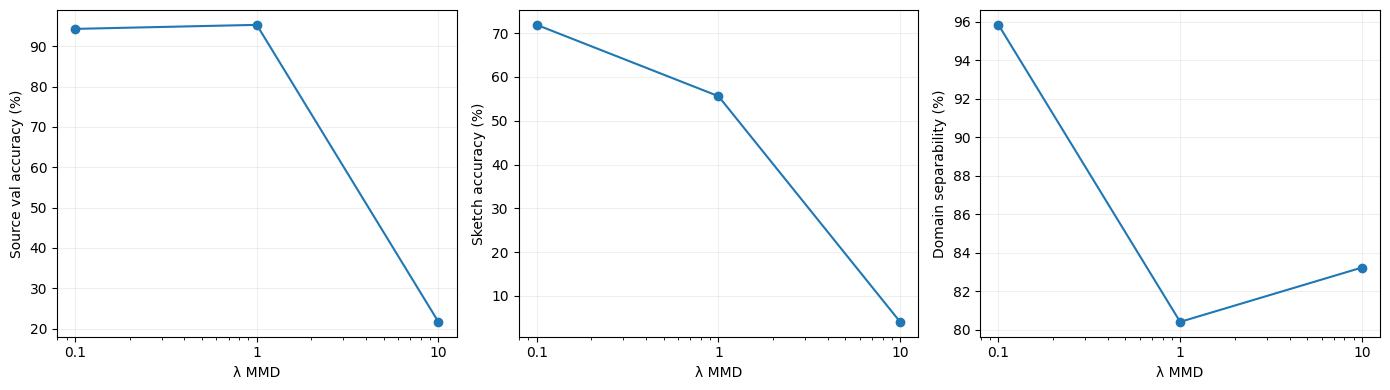

Saved figures: 9 | selected paired cases: 45


,method,case_type,hf_index,true_class,erm_predicted,method_predicted
0,dan,wrong_to_correct,6149,dog,elephant,dog
1,dan,wrong_to_correct,6158,dog,elephant,dog
2,dan,wrong_to_correct,6174,dog,giraffe,dog
3,dan,wrong_to_correct,6175,dog,elephant,dog
4,dan,wrong_to_correct,6177,dog,giraffe,dog
5,dan,correct_to_wrong,6103,dog,dog,house
6,dan,correct_to_wrong,6160,dog,dog,person
7,dan,correct_to_wrong,6161,dog,dog,person
8,dan,correct_to_wrong,6164,dog,dog,person
9,dan,correct_to_wrong,6167,dog,dog,person


In [9]:
#! Generate figures and pre-specified examples without choosing new model settings
FIG_DIR = RESULT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
positions = np.arange(len(MAIN_NAMES))

ax.bar(positions-0.18, MAIN_TABLE.source_mean_accuracy*100, width=0.36, label='Source val (mean)')
ax.bar(positions+0.18, MAIN_TABLE.target_accuracy*100, width=0.36, label='Sketch target')
ax.set_xticks(positions, MAIN_NAMES)
ax.set(xlabel='Frozen training objective', ylabel='Top-1 accuracy (%)', title='Source–target recognition gap')
ax.legend(); fig.tight_layout()

fig.savefig(FIG_DIR / 'source_target_accuracy.png', dpi=220); plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 4.5))

for _, row in MAIN_TABLE.iterrows():
    ax.scatter(row.domain_separability*100, row.target_accuracy*100, s=75)
    ax.annotate(row.method, (row.domain_separability*100, row.target_accuracy*100), xytext=(5, 4),
                textcoords='offset points')

ax.axvline(50, linestyle='--', color='gray', linewidth=1, label='Chance separability')
ax.set(xlabel='Held-out source-vs-Sketch domain accuracy (%)',
       ylabel='Sketch classification accuracy (%)', title='Domain information vs recognition')
ax.legend(); fig.tight_layout()

fig.savefig(FIG_DIR / 'separability_vs_target.png', dpi=220); plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name in MAIN_NAMES:
    history = pd.read_csv(TASK2_DIR / 'results' / name / 'history.csv')
    ce_column = 'train_loss' if name == 'source_only' else 'train_cls_loss'
    axes[0].plot(history.epoch, history[ce_column], label=name)

    if name != 'source_only':
        axes[1].plot(history.epoch, history.train_alignment_loss, label=name)

axes[0].set(title='Source classification CE', xlabel='Epoch', ylabel='CE')
axes[1].set(title='MMD² / domain CE (different objective scales)', xlabel='Epoch', ylabel='Alignment loss')

for ax in axes: ax.legend(); ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(FIG_DIR / 'training_loss_curves.png', dpi=220); plt.show(); plt.close(fig)

changes = CLASS_TABLE[CLASS_TABLE.method.isin(MAIN_NAMES)].pivot(
    index='class_name', columns='method', values='change_vs_erm_pp').reindex(
    index=LABEL_NAMES, columns=MAIN_NAMES)

fig, ax = plt.subplots(figsize=(8, 5))

limit = max(1.0, float(np.nanmax(np.abs(changes.to_numpy()))))

im = ax.imshow(changes.to_numpy(), cmap='coolwarm', vmin=-limit, vmax=limit, aspect='auto')
ax.set_xticks(range(len(MAIN_NAMES)), MAIN_NAMES)
ax.set_yticks(range(len(LABEL_NAMES)), LABEL_NAMES)
ax.set(title='Per-class Sketch accuracy change vs source-only (pp)')

fig.colorbar(im, ax=ax, label='Accuracy change (percentage points)')
fig.tight_layout(); fig.savefig(FIG_DIR / 'per_class_transfer.png', dpi=220)

plt.show(); plt.close(fig)

for name in MAIN_NAMES:
    matrix = CONFUSIONS[name]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(7), LABEL_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(7), LABEL_NAMES)
    ax.set(xlabel='Predicted class', ylabel='True class', title=f'Sketch confusion: {name}')

    fig.colorbar(im, ax=ax, label='Examples')
    fig.tight_layout(); fig.savefig(FIG_DIR / f'confusion_{name}.png', dpi=220)

    plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for col, (metric, ylabel) in enumerate([
    ('source_mean_accuracy', 'Source val accuracy (%)'),
    ('target_accuracy', 'Sketch accuracy (%)'),
    ('domain_separability', 'Domain separability (%)')]):

    axes[col].plot(CONTROL_TABLE.lambda_mmd, CONTROL_TABLE[metric]*100, marker='o')
    axes[col].set_xscale('log'); axes[col].set_xticks([0.1, 1, 10], ['0.1', '1', '10'])
    axes[col].set(xlabel='λ MMD', ylabel=ylabel)
    axes[col].grid(alpha=0.2)

fig.tight_layout(); fig.savefig(FIG_DIR / 'controlled_alignment_strength.png', dpi=220)
plt.show(); plt.close(fig)

#! Select paired outcomes deterministically without cherry-picking outcomes for a claim.
CASE_ROWS = []

for name in ['dan', 'dann', 'cdan']:
    current, baseline = PREDICTIONS[name], PREDICTIONS['source_only']
    for category, mask in [
        ('wrong_to_correct', (baseline != TARGET_TRUE) & (current == TARGET_TRUE)),
        ('correct_to_wrong', (baseline == TARGET_TRUE) & (current != TARGET_TRUE)),
        ('both_wrong', (baseline != TARGET_TRUE) & (current != TARGET_TRUE)),
    ]:
        candidates = np.flatnonzero(mask)
        #! First five by stable original HF index are a transparent case-selection rule.
        selected = candidates[np.argsort(TARGET_IDS[candidates])[:5]]
        for i in selected:
            CASE_ROWS.append({'method': name, 'case_type': category,
                              'hf_index': int(TARGET_IDS[i]),
                              'true_class': LABEL_NAMES[TARGET_TRUE[i]],
                              'erm_predicted': LABEL_NAMES[baseline[i]],
                              'method_predicted': LABEL_NAMES[current[i]]})

CASE_TABLE = pd.DataFrame(CASE_ROWS, columns=['method','case_type','hf_index','true_class',
                                               'erm_predicted','method_predicted'])

CASE_TABLE.to_csv(RESULT_DIR / 'selected_failure_cases.csv', index=False)
print('Saved figures:', len(list(FIG_DIR.glob('*.png'))), '| selected paired cases:', len(CASE_TABLE))

display(CASE_TABLE.head(12))

In [10]:
#! Verify required results and immutable original training files
REQUIRED_FINAL = [LOCK_PATH, RESULT_DIR / 'domain_probe_fixed_sample.json',
    RESULT_DIR / 'source_validation_all_methods.csv',
    RESULT_DIR / 'domain_separability_all_methods.csv',
    RESULT_DIR / 'target_metrics_all_methods.csv',
    RESULT_DIR / 'main_comparison.csv',
    RESULT_DIR / 'controlled_strength_final.csv',
    RESULT_DIR / 'per_class_target_transfer.csv',
    RESULT_DIR / 'paired_target_predictions.csv',
    RESULT_DIR / 'selected_failure_cases.csv']

for name in MODEL_SPECS:
    REQUIRED_FINAL.extend([CACHE_DIR / f'{name}_source_target_features.npz',
                           CACHE_DIR / f'{name}_metadata.json',
                           RESULT_DIR / f'confusion_{name}.csv'])

REQUIRED_FINAL.extend(FIG_DIR / filename for filename in [
    'source_target_accuracy.png', 'separability_vs_target.png',
    'training_loss_curves.png', 'per_class_transfer.png',
    'controlled_alignment_strength.png',
] + [f'confusion_{name}.png' for name in MAIN_NAMES])

missing = [str(p) for p in REQUIRED_FINAL if not p.is_file() or p.stat().st_size == 0]

if missing:
    raise FileNotFoundError('Incomplete final-evaluation outputs:\n' + '\n'.join(missing))

if len(MAIN_TABLE) != 4 or len(CONTROL_TABLE) != 3 or len(CLASS_TABLE) != 6 * 7:
    raise RuntimeError('Unexpected method or class counts in evaluation results')

if len(pd.read_csv(RESULT_DIR / 'paired_target_predictions.csv')) != len(TARGET_ROWS):
    raise RuntimeError('Target prediction records omit images')

if sha256(BASE_PATH) != FROZEN_PLAN['base_config_sha256'] or sha256(SPLIT_PATH) != FROZEN_PLAN['source_split_sha256']:
    raise RuntimeError('Original protocol modified since evaluation freeze')

if sha256(STUDY_PATH) != FROZEN_PLAN['study_plan_sha256']:
    raise RuntimeError('Controlled study plan modified after target-label release')

if sha256(STUDY_DIR / 'source_only_selection.json') != FROZEN_PLAN['source_choice_sha256']:
    raise RuntimeError('Source-only lambda choice modified after target-label release')

for name, entry in FROZEN_PLAN['models'].items():
    for key, digest in [('config_path', entry['config_sha256']),
                        ('best_path', entry['best_sha256']),
                        ('last_path', entry['last_sha256'])]:
        if sha256(Path(entry[key])) != digest:
            raise RuntimeError(f'Original {name} artifact changed AFTER final evaluation: {key}')

FINAL_MANIFEST = {
    'final_evaluation_only': True, 'seed': SEED, 'output_files': len(REQUIRED_FINAL),
    'target_evaluated_images': int(len(TARGET_TRUE)),
    'models': list(MODEL_SPECS),
    'source_only_choice_frozen_before_target_labels': True,
    'original_model_checkpoints_unchanged': True,
    'domain_probe': 'balanced logistic regression, C=1, seed=6304, 70/30 held out',
    'caveat': 'Do not use Task 2 Sketch labels/results to choose Task 3 training or hyperparameters',
}

(RESULT_DIR / 'verification.json').write_text(json.dumps(FINAL_MANIFEST, indent=2))

print('TASK 2G FINAL EVALUATION COMPLETE')
print('Verified result files:', len(REQUIRED_FINAL), '| checkpoints:', len(MODEL_SPECS))
print('No model training or target-label-based selection occurred in this notebook.')

TASK 2G FINAL EVALUATION COMPLETE
Verified result files: 37 | checkpoints: 6
No model training or target-label-based selection occurred in this notebook.
